#  Предсказание породы собак по фотографии

На этом этапе мы загружаем все необходимые инструменты (библиотеки):

- NumPy, OpenCV (cv2), skimage: для работы с изображениями (загрузка, изменение размера, извлечение признаков).

- Sklearn: для построения и оценки моделей машинного обучения (случайный лес, градиентный бустинг, метод опорных векторов, нормализация данных, снижение размерности).

- Matplotlib, Seaborn: для визуализации результатов (графики, матрица ошибок).

- Collections, warnings: для вспомогательных операций (подсчет данных, игнорирование предупреждений).

In [1]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage import exposure
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

D:\Conda2\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Задаем пути к папкам с изображениями и аннотациями.

In [2]:
ANNOTATIONS_PATH = r'D:\Dogs\annotations\Annotation'
IMAGES_PATH = r'D:\Dogs\images\Images'

### Функция для загрузки изображений с диска и их подготовки.

Функция сканирует все подпапки в IMAGES_PATH, где каждая папка соответствует одной породе собак.
Параметр max_images_per_class ограничивает количество изображений, загружаемых для каждой породы. Это делается для балансировки классов и ускорения обучения.
Изображения загружаются с помощью cv2.imread и изменяются до единого размера (128x128 пикселей), чтобы все входные данные имели одинаковую размерность.
Название породы извлекается из имени папки.
Функция возвращает массив NumPy с изображениями (X_raw) и список с соответствующими метками пород (y_raw).

In [3]:
def load_all_breeds(images_path, max_images_per_class=50, img_size=(128, 128)):
    images = []
    labels = []
    skipped_classes = []

    breed_folders = [f for f in os.listdir(images_path) 
                     if os.path.isdir(os.path.join(images_path, f))]
    for breed_idx, breed_folder in enumerate(breed_folders):
        breed_path = os.path.join(images_path, breed_folder)
        img_files = [f for f in os.listdir(breed_path) 
                    if f.endswith(('.jpg', '.jpeg', '.png'))]
        if max_images_per_class:
            img_files = img_files[:max_images_per_class]
        
        if len(img_files) == 0:
            skipped_classes.append(breed_folder)
            continue

        successful_loads = 0
        for img_file in img_files:
            img_path = os.path.join(breed_path, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.resize(img, img_size)
                images.append(img)
                breed_name = breed_folder.split('-', 1)[1] if '-' in breed_folder else breed_folder
                labels.append(breed_name)
                successful_loads += 1
        
    return np.array(images), np.array(labels)

X_raw, y_raw = load_all_breeds(IMAGES_PATH, max_images_per_class=50, img_size=(128, 128))

### Визуализация загруженных данных
Первичная проверка: правильно ли загрузились изображения, соответствуют ли они своим породам. 

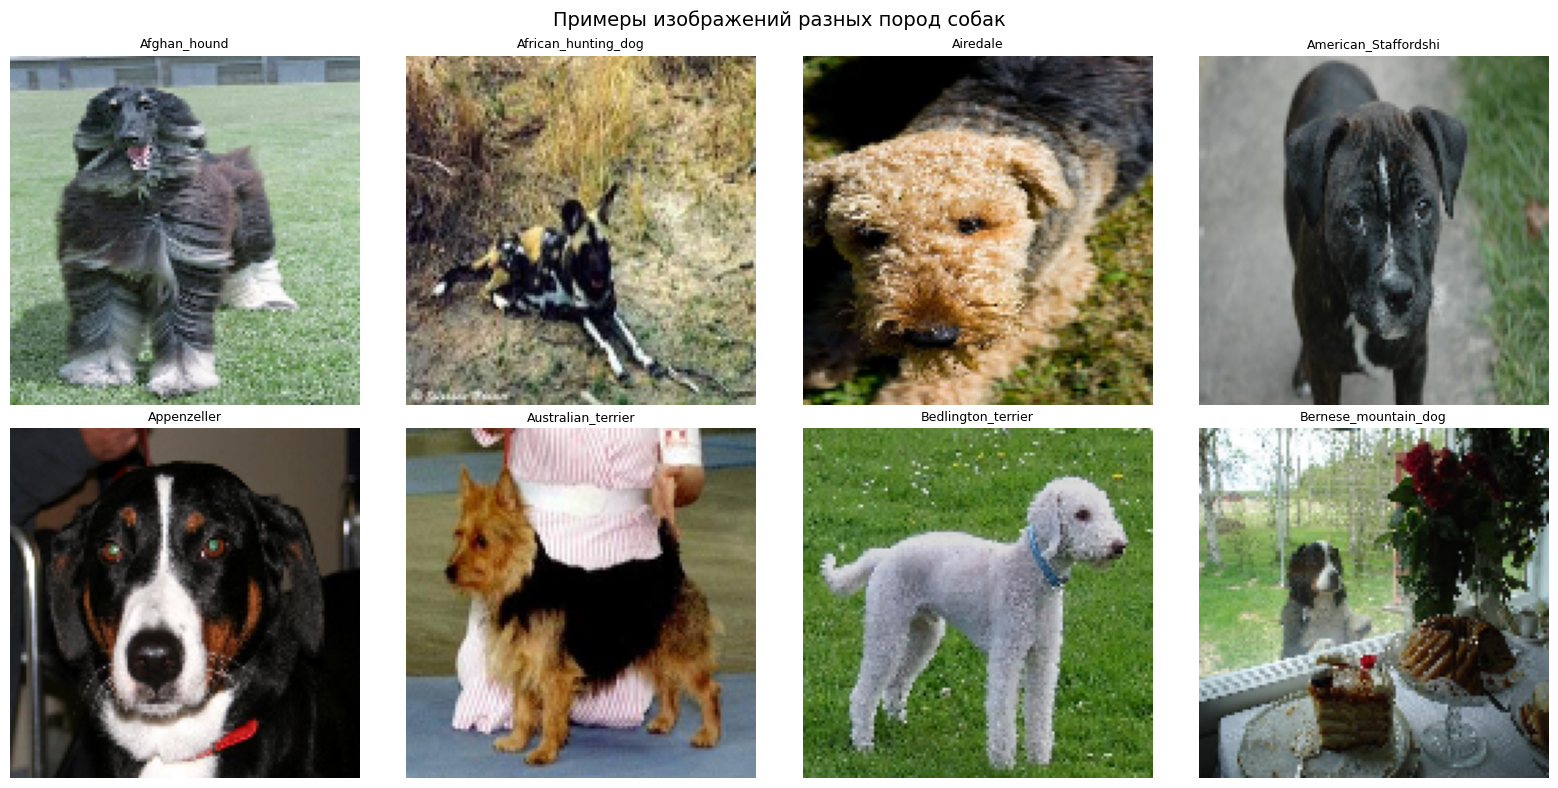

In [4]:
def visualize_samples(images, labels, num_samples=8):
    unique_breeds = np.unique(labels)
    plt.figure(figsize=(16, 8))
    
    for i, breed in enumerate(unique_breeds[:num_samples]):
        breed_indices = np.where(labels == breed)[0]
        if len(breed_indices) > 0:
            img_idx = breed_indices[0]
            img = cv2.cvtColor(images[img_idx], cv2.COLOR_BGR2RGB)
            
            plt.subplot(2, num_samples//2, i+1)
            plt.imshow(img)
            plt.title(f'{breed[:20]}', fontsize=9)
            plt.axis('off')
    
    plt.suptitle('Примеры изображений разных пород собак', fontsize=14)
    plt.tight_layout()
    plt.show()
visualize_samples(X_raw, y_raw, num_samples=8)

### Функция извлечения признаков
Преобразуем каждое изображение в набор числовых признаков, которые описывают его визуальные характеристики. Для этого испоьзуем несколько техник:

- Цветовая гистограмма (Color Histogram): Показывает распределение цветов (красный, зеленый, синий каналы).

- HOG (Histogram of Oriented Gradients): Подсчитывает, как часто градиенты (направления изменения яркости) появляются в различных локальных участках изображения.

- LBP (Local Binary Patterns): Описывает локальную структуру изображения, кодируя отношения между центральным пикселем и его соседями.

- GLCM (Gray-Level Co-occurrence Matrix): Статистический метод, анализирующий, как часто пары пикселей с определенными значениями яркости встречаются на заданном расстоянии и направлении. Извлекаем характеристики контрастность и энергия.

In [5]:
def extract_advanced_features(images, batch_size=50):
    features_list = []
    total_images = len(images)
    
    for i in range(0, total_images, batch_size):
        batch = images[i:min(i+batch_size, total_images)]
        batch_features = []
        
        for img in batch:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            
            hog_feat = hog(gray, orientations=12, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=False,
                          feature_vector=True, block_norm='L2-Hys')
            
            radius = 2
            n_points = 8 * radius
            lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
            lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), 
                                       range=(0, n_points + 2))
            lbp_hist = lbp_hist / (np.sum(lbp_hist) + 1e-6)
            
            color_features = []
            
            for color_space in [img, hsv, lab]:
                for channel in range(3):
                    channel_data = color_space[:, :, channel].flatten()
                    
                    hist = cv2.calcHist([color_space], [channel], None, [32], [0, 256])
                    color_features.extend(hist.flatten())
                    
                    color_features.extend([
                        np.mean(channel_data),
                        np.std(channel_data),
                        np.median(channel_data),
                        np.percentile(channel_data, 25),
                        np.percentile(channel_data, 75),
                    ])

            try:
                glcm = graycomatrix(gray, [1], [0, np.pi/4, np.pi/2], 256, symmetric=True)
                contrast = graycoprops(glcm, 'contrast').flatten()
                dissimilarity = graycoprops(glcm, 'dissimilarity').flatten()
                homogeneity = graycoprops(glcm, 'homogeneity').flatten()
                energy = graycoprops(glcm, 'energy').flatten()
                correlation = graycoprops(glcm, 'correlation').flatten()
                glcm_features = np.concatenate([contrast, dissimilarity, homogeneity, energy, correlation])
            except:
                glcm_features = np.zeros(15)
            
            edges = cv2.Canny(gray, 50, 150)
            edge_density = np.sum(edges > 0) / edges.size
            
            orb = cv2.ORB_create(nfeatures=30)
            keypoints, descriptors = orb.detectAndCompute(gray, None)
            orb_features = [min(len(keypoints), 30) / 30.0]
            if descriptors is not None:
                orb_features.extend([np.mean(descriptors), np.std(descriptors)])
            else:
                orb_features.extend([0, 0])

            combined = np.hstack([
                hog_feat,
                lbp_hist,
                color_features,
                glcm_features,
                [edge_density],
                orb_features
            ])
            
            batch_features.append(combined)
        
        features_list.extend(batch_features)
    return np.array(features_list, dtype=np.float32)

X_features = extract_advanced_features(X_raw, batch_size=50)

### Функция аугментации данных
Для повышения обобщающей способности модели и снижения риска переобучения применяется аугментация — создание искусственно изменённых копий исходных изображений. Функция augment_dataset для каждого изображения генерирует augment_factor - 1 дополнительных вариантов. Поддерживаются четыре типа преобразований:

- Flip (отражение) — горизонтальное зеркалирование.
- Rotate (поворот) — случайный угол в диапазоне от -15 до +15 градусов.
- Brightness (изменение яркости) — масштабирование канала яркости HSV с коэффициентом 0.7–1.3.
- Noise (шум) — добавление случайных пиксельных значений до 20.

Тип преобразования выбирается случайным образом для каждого нового варианта.

In [6]:
def augment_dataset(images, labels, augment_factor=2):
    augmented_images = []
    augmented_labels = []
    
    for idx, (img, label) in enumerate(zip(images, labels)):
        augmented_images.append(img)
        augmented_labels.append(label)
        
        for aug_idx in range(augment_factor - 1):
            aug_img = img.copy()
            
            aug_type = np.random.choice(['flip', 'rotate', 'brightness', 'noise'])
            
            if aug_type == 'flip':
                aug_img = cv2.flip(aug_img, 1)
            elif aug_type == 'rotate':
                angle = np.random.randint(-15, 16)
                h, w = aug_img.shape[:2]
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
                aug_img = cv2.warpAffine(aug_img, M, (w, h))
            elif aug_type == 'brightness':
                hsv = cv2.cvtColor(aug_img, cv2.COLOR_BGR2HSV)
                hsv[:, :, 2] = np.clip(hsv[:, :, 2] * np.random.uniform(0.7, 1.3), 0, 255)
                aug_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
            elif aug_type == 'noise':
                noise = np.random.randint(0, 20, aug_img.shape, dtype=np.uint8)
                aug_img = cv2.add(aug_img, noise)
            
            augmented_images.append(aug_img)
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

X_augmented, y_augmented = augment_dataset(X_raw, y_raw, augment_factor=2)

Извлечение признаков после аугментации.

In [7]:
X_features_aug = extract_advanced_features(X_augmented, batch_size=50)

### Подготовка целевых меток и разделение данных, нормализация данных, снижение размерности
Строковые названия пород преобразуются в числовые идентификаторы с помощью LabelEncoder. Это необходимо для корректной работы алгоритмов машинного обучения, которые требуют числовых целевых переменных. Далее данные разделяются на обучающую (80%) и тестовую (20%) выборки с использованием train_test_split. Параметр stratify=y_encoded обеспечивает сохранение исходного распределения классов в обеих выборках — критически важно для несбалансированных датасетов.

Поскольку извлечённые признаки имеют различные масштабы (цветовые гистограммы лежат в диапазоне 0–255, а HOG и LBP — в других пределах), необходимо выполнить стандартизацию. StandardScaler преобразует каждый признак так, чтобы его среднее значение стало равным 0, а стандартное отклонение — 1. Это обязательный шаг для алгоритмов, чувствительных к масштабу признаков, таких как KNN и PCA.

Исходный признаковый вектор имеет высокую размерность (порядка 8000–9000 признаков), что замедляет обучение. Для решения этой проблемы применяется метод главных компонент (PCA). Параметр n_components=0.95 означает, что выбирается минимальное количество главных компонент, сохраняющих 95% суммарной дисперсии исходных данных.

In [8]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_augmented)
n_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_features_aug, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### Ансамблевая модель
Вместо использования одного классификатора применяется ансамблевая стратегия — объединение нескольких моделей с голосованием. 

- Random Forest (200 деревьев, максимальная глубина 20) — устойчив к переобучению, хорошо работает с табличными признаками.
- Gradient Boosting (150 итераций, скорость обучения 0.1) — последовательно исправляет ошибки предыдущих моделей.
- KNN (5 ближайших соседей, взвешивание расстоянием) — простой, но эффективный метод, основанный на близости в пространстве признаков.

Ансамбль создаётся с помощью VotingClassifier с параметром voting='soft' — итоговое предсказание определяется как среднее вероятностей классов от всех моделей. 

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=1
)

try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )
    use_xgb = True
except:
    use_xgb = False

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski'
)

if use_xgb:
    estimators = [('rf', rf), ('gb', gb), ('xgb', xgb), ('knn', knn)]
else:
    estimators = [('rf', rf), ('gb', gb), ('knn', knn)]

ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

### Обучение модели и расчёт точности
Ансамблевая модель обучается на подготовленных данных с помощью метода fit. После завершения обучения выполняются предсказания для тестовой выборки (predict). Точность модели вычисляется как доля правильных ответов с помощью accuracy_score. Результат выводится в удобном процентном формате. Данная метрика является основной для оценки качества классификации, однако для многоклассовой задачи также важны precision, recall и F1-мера, которые будут проанализированы далее.

In [10]:
ensemble.fit(X_train_pca, y_train)

In [11]:
y_pred = ensemble.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f"ТОЧНОСТЬ МОДЕЛИ: {accuracy:.2%}")

ТОЧНОСТЬ МОДЕЛИ: 74.30%


### Детальный анализ ошибок классификации

Для углублённой оценки качества модели строятся два отчёта:

Classification Report — для каждой породы выводятся precision (точность), recall (полнота) и F1-мера. Это позволяет выявить классы, которые модель распознаёт хуже всего.

Матрица ошибок (confusion matrix) — визуализируется в виде тепловой карты. По диагонали отображаются правильные предсказания, вне диагонали — ошибки. Матрица строится для первых 10 пород для наглядности. Цветовая схема YlOrRd (от жёлтого к тёмно-красному) позволяет быстро идентифицировать наиболее проблемные пары классов, где модель часто путает похожие породы.


ОТЧЕТ ПО КЛАССАМ (первые 15 пород):
Chihuahua                          : 65.02% (31 фото)
Japanese_spaniel                   : 87.82% (44 фото)
Maltese                            : 79.20% (39 фото)
Pekinese                           : 79.07% (35 фото)
Shih-Tzu                           : 65.16% (32 фото)
Blenheim_spaniel                   : 65.53% (31 фото)
papillon                           : 77.07% (43 фото)
toy_terrier                        : 74.20% (35 фото)
Rhodesian_ridgeback                : 66.07% (35 фото)
Afghan_hound                       : 87.40% (28 фото)
basset_hound                       : 70.35% (32 фото)
beagle                             : 67.08% (27 фото)
bloodhound                         : 79.22% (26 фото)
bluetick                           : 73.80% (36 фото)
black-and-tan_coonhound            : 87.61% (30 фото)

ПОЛНЫЙ ОТЧЕТ:
                     precision  recall     f1-score   support   
Chihuahua            0.68       0.65       0.66       31        
Japanese

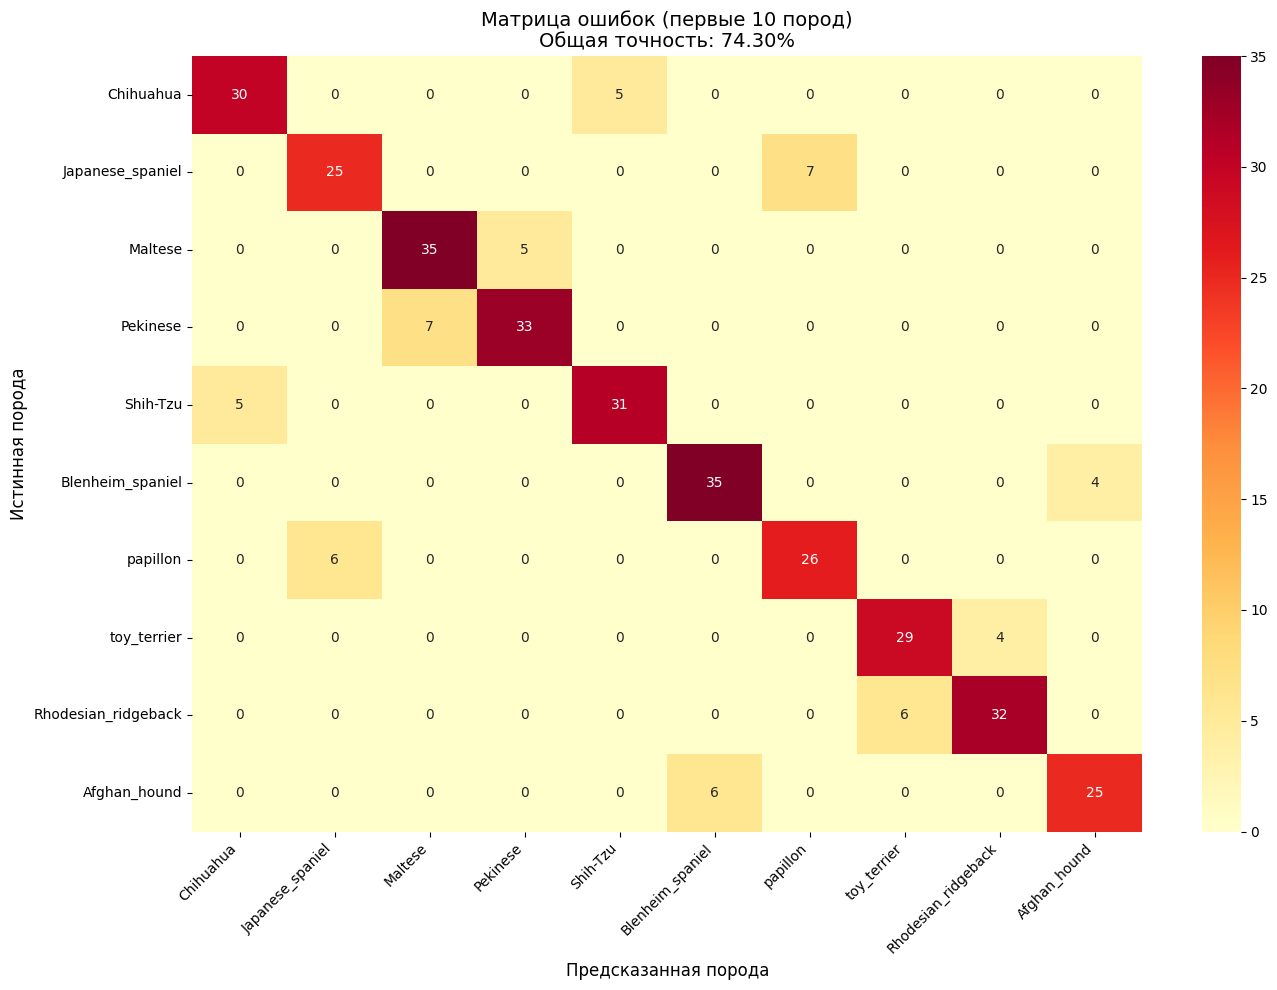

In [12]:
print(f"\nОТЧЕТ ПО КЛАССАМ (первые 15 пород):")
unique_classes = np.unique(y_test)[:15]
for class_idx in unique_classes:
    class_mask = y_test == class_idx
    if np.sum(class_mask) > 0:
        class_acc = np.sum(y_pred[class_mask] == class_idx) / np.sum(class_mask)
        breed_name = label_encoder.inverse_transform([class_idx])[0]
        print(f"{breed_name[:35]:35s}: {class_acc:.2%} ({np.sum(class_mask)} фото)")

print(f"\n ПОЛНЫЙ ОТЧЕТ:")
print(classification_report(y_test, y_pred, 
                          target_names=label_encoder.classes_[:min(20, len(label_encoder.classes_))],
                          zero_division=0))

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
cm_subset = cm[:10, :10]

sns.heatmap(cm_subset, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_encoder.classes_[:10],
            yticklabels=label_encoder.classes_[:10])
plt.title(f'Матрица ошибок (первые 10 пород)\nОбщая точность: {accuracy:.2%}', fontsize=14)
plt.xlabel('Предсказанная порода', fontsize=12)
plt.ylabel('Истинная порода', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Функция классификации одного изображения
Функция принимает путь к произвольному изображению и обученные объекты (модель, scaler, pca, label_encoder). Внутри функции выполняются те же шаги предобработки, что и для обучающих данных: загрузка изображения, изменение размера до 128×128, извлечение признаков (цветовая гистограмма, HOG, LBP, GLCM), стандартизация, снижение размерности и, наконец, предсказание. Результатом является строковое название породы. Важно, что все преобразования (особенно параметры PCA и стандартизации) должны быть идентичны тем, которые применялись к обучающей выборке, что обеспечивается использованием сохранённых объектов scaler и pca.

In [13]:
def predict_dog_breed(image_path, model, scaler, pca, label_encoder):
    img = cv2.imread(image_path)
    
    original_img = img.copy()
    img_resized = cv2.resize(img, (128, 128))
    
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    
    hog_feat = hog(gray, orientations=12, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), visualize=False,
                  feature_vector=True, block_norm='L2-Hys')
    
    radius = 2
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), 
                               range=(0, n_points + 2))
    lbp_hist = lbp_hist / (np.sum(lbp_hist) + 1e-6)
    
    color_features = []
    for color_space in [img_resized, hsv, lab]:
        for channel in range(3):
            channel_data = color_space[:, :, channel].flatten()
            hist = cv2.calcHist([color_space], [channel], None, [32], [0, 256])
            color_features.extend(hist.flatten())
            color_features.extend([
                np.mean(channel_data), np.std(channel_data),
                np.median(channel_data), np.percentile(channel_data, 25),
                np.percentile(channel_data, 75)
            ])
    
    try:
        glcm = graycomatrix(gray, [1], [0, np.pi/4, np.pi/2], 256, symmetric=True)
        contrast = graycoprops(glcm, 'contrast').flatten()
        dissimilarity = graycoprops(glcm, 'dissimilarity').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()
        glcm_features = np.concatenate([contrast, dissimilarity, homogeneity, energy, correlation])
    except:
        glcm_features = np.zeros(15)
    
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    
    orb = cv2.ORB_create(nfeatures=30)
    keypoints, descriptors = orb.detectAndCompute(gray, None)
    orb_features = [min(len(keypoints), 30) / 30.0]
    if descriptors is not None:
        orb_features.extend([np.mean(descriptors), np.std(descriptors)])
    else:
        orb_features.extend([0, 0])
    
    features = np.hstack([hog_feat, lbp_hist, color_features, glcm_features, 
                         [edge_density], orb_features]).reshape(1, -1)

    features_scaled = scaler.transform(features)
    features_pca = pca.transform(features_scaled)

    prediction = model.predict(features_pca)
    breed = label_encoder.inverse_transform(prediction)[0]

    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(features_pca)[0]
        top_3_idx = np.argsort(probabilities)[-3:][::-1]
        
        print("\n3 НАИБОЛЕЕ ВЕРОЯТНЫХ ПОРОДЫ:")
        for idx in top_3_idx:
            print(f"  {idx+1}. {label_encoder.classes_[idx]}: {probabilities[idx]:.2%}")

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title('Загруженное фото', fontsize=12)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    img_processed = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    plt.imshow(img_processed)
    plt.title('Обработанное фото (128×128)', fontsize=12)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    _, hog_image = hog(gray, orientations=12, pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2), visualize=True)
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title(f'ПОРОДА: {breed.upper()}', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.suptitle(f'РЕЗУЛЬТАТ РАСПОЗНАВАНИЯ', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return breed

### Тестирование на произвольной фотографии
Демонстрация работы разработанной системы. В переменной test указывается путь к файлу с изображением собаки (например, dog.jpg). Вызывается функция predict_dog_breed, которая возвращает предсказанную породу. Результат выводится в консоль. Данный пример служит для проверки работоспособности модели в условиях, приближенных к реальному использованию.

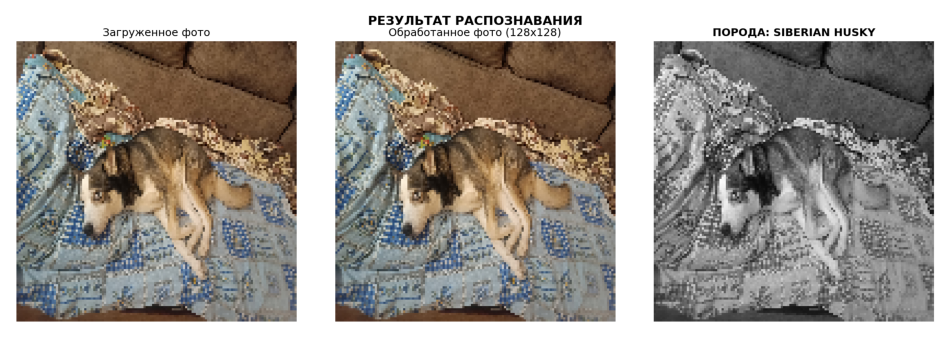

  Предсказанная порода: Siberian Husky


In [20]:
test = 'dog.jpg'
predicted_breed = predict_dog_breed(temp_path, ensemble, scaler, pca, label_encoder)
print(f"  Предсказанная порода: {predicted_breed}")